# ML.ENERGY Phase 1.7 — complete ex-ante feature audit

## tl;dr

- Scope is exactly 694 ML.ENERGY V3 GPU-side text-LLM inference runs; 565 satisfy the prior stability rule.
- Base ex-ante inputs cover 694/694 runs, reliable benchmark + effective workload covers 464/694, and supported physics proxies cover 383/694.
- All 132 Meta Llama runs remain in the master table but are restricted because authorized access was rejected; no mirror or substitute tokenizer/config was used.
- GPU energy/power fields are Y only. Actual output, throughput, latency, duration, batch behavior, telemetry, and stability outcomes never enter X.
- This notebook is descriptive. No formal prediction model is trained.

## Context and methods

The notebook reads versioned Phase 1.7 tables. `benchmark_*` means the benchmark/client `SampleRequest.prompt_len`; `effective_*` adds the pinned vLLM message normalization and model chat template, or the official FIM renderer. Physics fields are transparent upper-bound/proxy calculations, not measurements. Missing or unsupported values remain null with a reason.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
ANALYSIS = ROOT / "step3" / "analysis"
REPORTS = ROOT / "step3" / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

master = pd.read_parquet(ANALYSIS / "master_feature_table.parquet")
models = pd.read_parquet(ANALYSIS / "model_architecture_features.parquet")
roles = json.loads((ANALYSIS / "feature_role_manifest.json").read_text("utf-8"))["columns"]
coverage = json.loads((REPORTS / "eligibility_coverage.json").read_text("utf-8"))

assert len(master) == 694 and master["run_key"].nunique() == 694
assert int(master["diag_quality_is_stable"].sum()) == 565
assert int(master["eligible_base_exante"].sum()) == 694
assert int(master["eligible_full_workload"].sum()) == 464
assert int(master["eligible_physics_feature"].sum()) == 383
print({"runs": len(master), "stable": 565, "base": 694, "full_workload": 464, "physics": 383})

{'runs': 694, 'stable': 565, 'base': 694, 'full_workload': 464, 'physics': 383}


## Data-quality profile

In [2]:
quality = pd.DataFrame({
    "metric": ["unique run keys", "non-null GPU targets", "base eligible", "full workload eligible", "physics eligible", "stable"],
    "runs": [
        master["run_key"].nunique(),
        int(master[[c for c in master if c.startswith("y_gpu_")]].notna().all(axis=1).sum()),
        int(master["eligible_base_exante"].sum()),
        int(master["eligible_full_workload"].sum()),
        int(master["eligible_physics_feature"].sum()),
        int(master["eligible_primary_stable"].sum()),
    ],
})
quality

,metric,runs
0,unique run keys,694
1,non-null GPU targets,694
2,base eligible,694
3,full workload eligible,464
4,physics eligible,383
5,stable,565


## Workload coverage

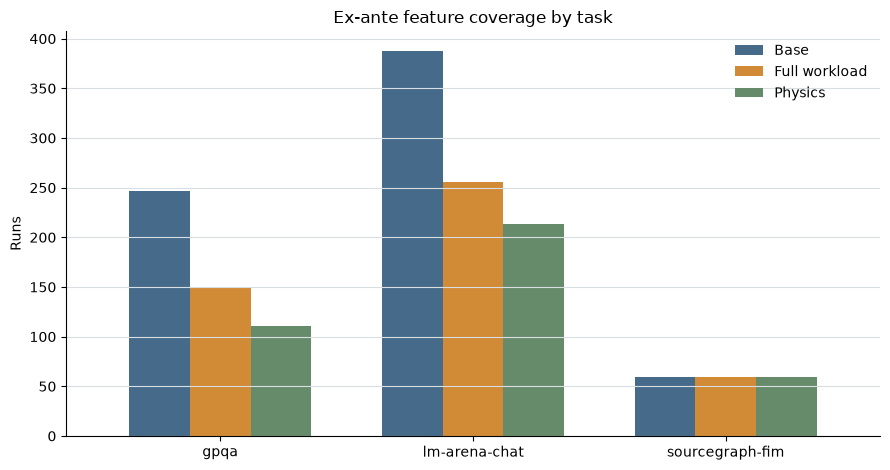

,eligible_base_exante,eligible_full_workload,eligible_physics_feature
x_protocol_task,,,
gpqa,247,149,111
lm-arena-chat,388,256,213
sourcegraph-fim,59,59,59


In [3]:
by_task = master.groupby("x_protocol_task")[["eligible_base_exante", "eligible_full_workload", "eligible_physics_feature"]].sum()
ax = by_task.plot(kind="bar", figsize=(9, 4.8), color=["#466B8A", "#D18A36", "#668B6B"], width=0.72)
ax.set_title("Ex-ante feature coverage by task")
ax.set_ylabel("Runs")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Base", "Full workload", "Physics"], frameon=False)
ax.grid(axis="y", color="#D9DEE3", linewidth=.8)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.savefig(FIGURES / "coverage_by_task.png", dpi=160); plt.show()
by_task

## Benchmark vs effective input

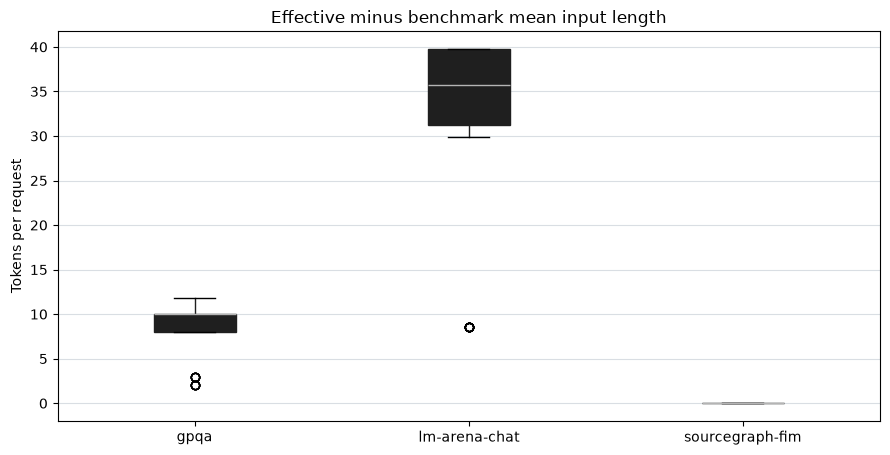

,count,min,median,mean,max
x_protocol_task,,,,,
gpqa,149,2.000000,10.000000,9.192394,11.833333
lm-arena-chat,256,8.552734,35.759766,34.099731,39.759766
sourcegraph-fim,59,0.000000,0.000000,0.000000,0.000000


In [4]:
resolved = master[master["eligible_full_workload"]].copy()
resolved["mean_token_delta"] = resolved["x_workload_effective_input_tokens_mean"] - resolved["x_workload_benchmark_input_tokens_mean"]
delta_summary = resolved.groupby("x_protocol_task")["mean_token_delta"].agg(["count", "min", "median", "mean", "max"])
ax = resolved.boxplot(column="mean_token_delta", by="x_protocol_task", figsize=(9, 4.8), grid=False, patch_artist=True)
plt.suptitle(""); ax.set_title("Effective minus benchmark mean input length")
ax.set_xlabel(""); ax.set_ylabel("Tokens per request")
ax.grid(axis="y", color="#D9DEE3", linewidth=.8)
plt.tight_layout(); plt.savefig(FIGURES / "benchmark_effective_delta.png", dpi=160); plt.show()
delta_summary

The difference is zero for resolved Sourcegraph FIM runs. Chat tasks generally add system/role/template tokens. Differences are not calibrated with post-run totals.

## Canonical model missingness

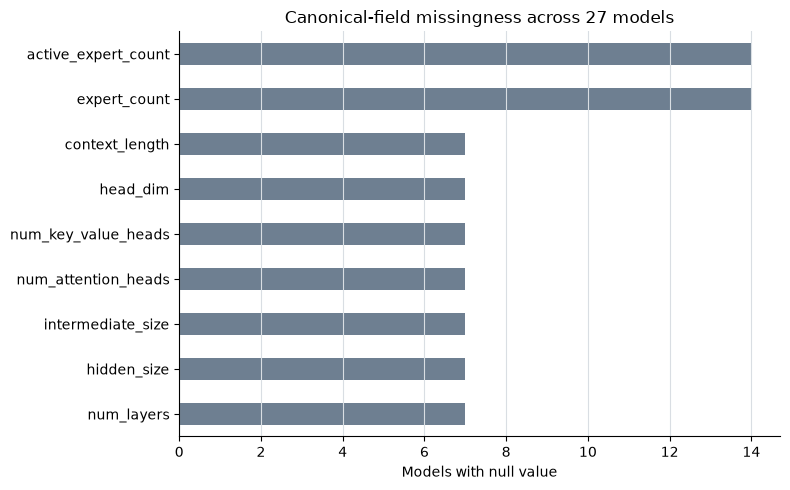

,models
config_status,
available,20
restricted,7


In [5]:
canonical = ["num_layers", "hidden_size", "intermediate_size", "num_attention_heads", "num_key_value_heads", "head_dim", "context_length", "expert_count", "active_expert_count"]
missing = models[canonical].isna().sum().sort_values()
ax = missing.plot(kind="barh", figsize=(8, 5), color="#6E7F91")
ax.set_title("Canonical-field missingness across 27 models")
ax.set_xlabel("Models with null value")
ax.grid(axis="x", color="#D9DEE3", linewidth=.8)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.savefig(FIGURES / "canonical_missingness.png", dpi=160); plt.show()
models["config_status"].value_counts().to_frame("models")

## Physics eligibility

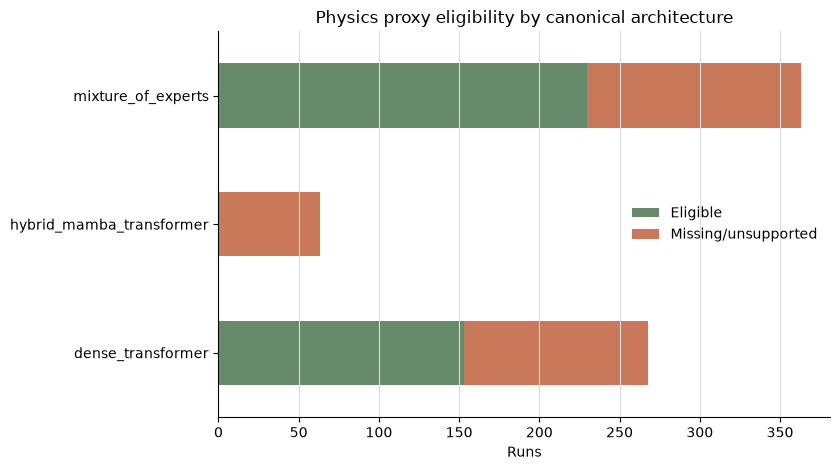

,sum,count,unavailable_or_unsupported
x_model_architecture_family,,,
dense_transformer,153,268,115
hybrid_mamba_transformer,0,63,63
mixture_of_experts,230,363,133


In [6]:
physics = master.groupby("x_model_architecture_family")["eligible_physics_feature"].agg(["sum", "count"])
physics["unavailable_or_unsupported"] = physics["count"] - physics["sum"]
ax = physics[["sum", "unavailable_or_unsupported"]].plot(kind="barh", stacked=True, figsize=(8.5, 4.8), color=["#668B6B", "#C9785A"])
ax.set_title("Physics proxy eligibility by canonical architecture")
ax.set_xlabel("Runs"); ax.set_ylabel("")
ax.legend(["Eligible", "Missing/unsupported"], frameon=False)
ax.grid(axis="x", color="#D9DEE3", linewidth=.8)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.savefig(FIGURES / "physics_eligibility.png", dpi=160); plt.show()
physics

## Llama access impact

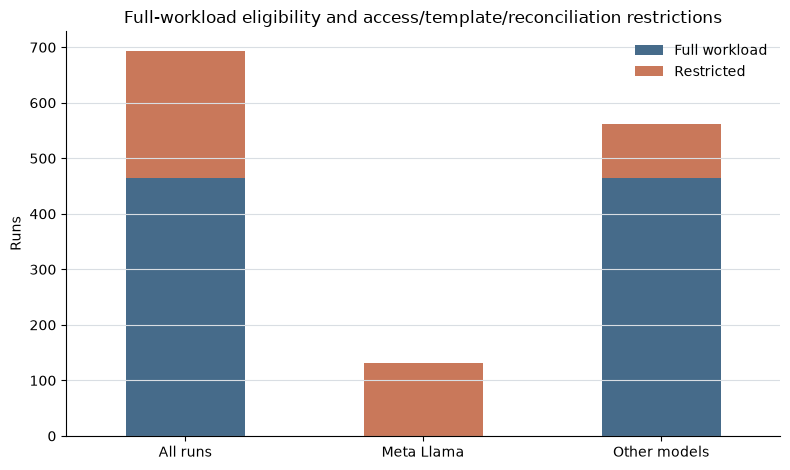

,subset,runs,full_workload,restricted
0,All runs,694,464,230
1,Meta Llama,132,0,132
2,Other models,562,464,98


In [7]:
access = pd.DataFrame({
    "subset": ["All runs", "Meta Llama", "Other models"],
    "runs": [len(master), int(master["diag_model_id"].str.startswith("meta-llama/").sum()), int((~master["diag_model_id"].str.startswith("meta-llama/")).sum())],
    "full_workload": [int(master["eligible_full_workload"].sum()), int(master.loc[master["diag_model_id"].str.startswith("meta-llama/"), "eligible_full_workload"].sum()), int(master.loc[~master["diag_model_id"].str.startswith("meta-llama/"), "eligible_full_workload"].sum())],
})
access["restricted"] = access["runs"] - access["full_workload"]
ax = access.set_index("subset")[["full_workload", "restricted"]].plot(kind="bar", stacked=True, figsize=(8, 4.8), color=["#466B8A", "#C9785A"])
ax.set_title("Full-workload eligibility and access/template/reconciliation restrictions")
ax.set_ylabel("Runs"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
ax.legend(["Full workload", "Restricted"], frameon=False)
ax.grid(axis="y", color="#D9DEE3", linewidth=.8)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.savefig(FIGURES / "llama_access_impact.png", dpi=160); plt.show()
access

## Takeaways

1. The 694-run base table supports a Phase 2 GPU-side baseline using only execution-time-known fields; stability is a selection rule, not X.
2. Reliable effective-workload modeling is supported for 464 runs; physics-enhanced sensitivity analysis is supported for 383 runs. The 39 historical GPQA mismatches are retained but excluded because equivalence to the pinned request vector cannot be proven.
3. Meta Llama remains a documented access limitation, and gpt-oss Harmony behavior remains unresolved without a recorded historical runtime package version.
4. Pure-Transformer formulas are not forced onto Nemotron hybrid or DeepSeek MLA rows.
5. Output-token caps and decode work are upper-bound scenarios, not actual or expected generated work.
6. RAPL zone 1 remains a platform-like diagnostic and is outside this GPU-target master table.
7. Phase 1.7 stops here; no formal prediction model is trained.